<a href="https://colab.research.google.com/github/Chaitanya15-ai/OIBSIP/blob/main/ChaitanyaSawant_Task1(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RETAIL SALES DATASET ANALYSIS

Dataset Shape:
(1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

First 5 Records:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

Last 5 Records:
     Transaction ID        Date Customer ID  Gender  A

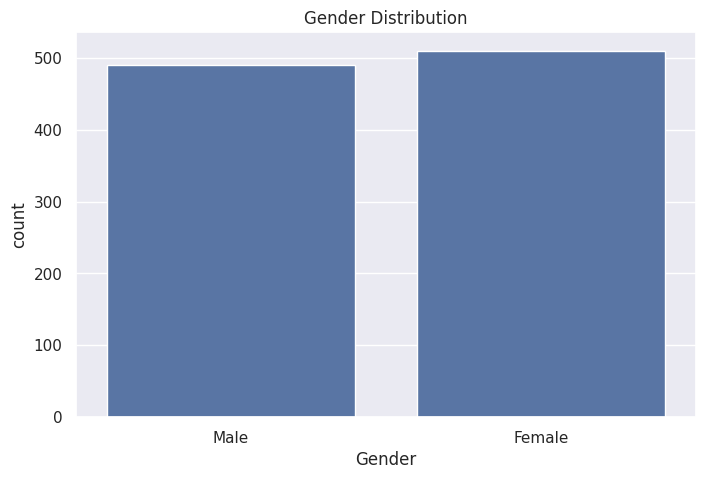

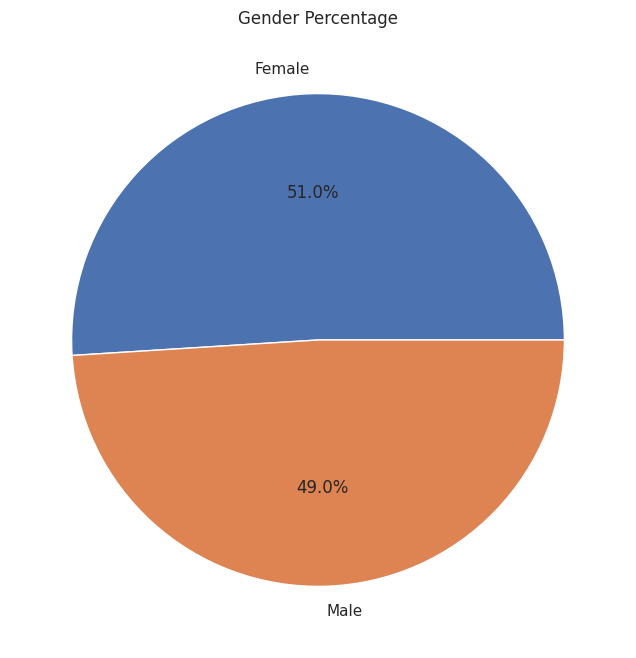

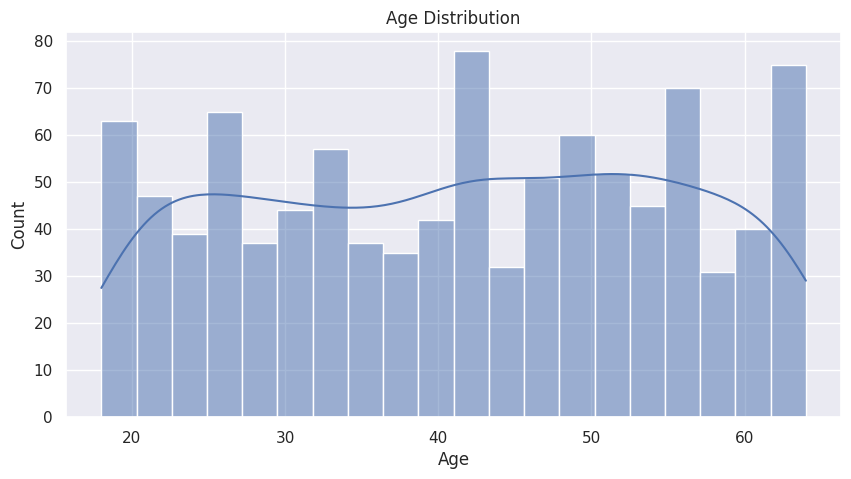

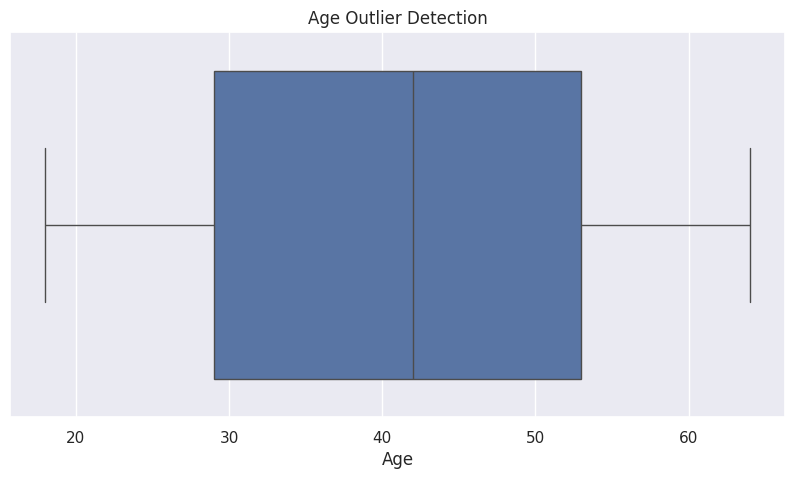

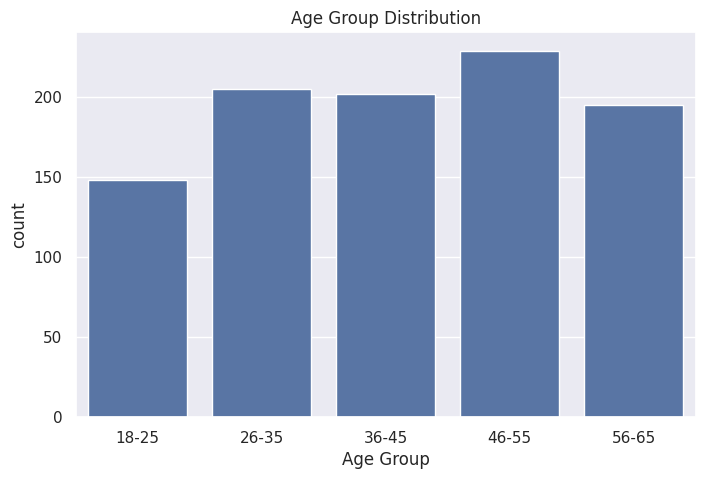

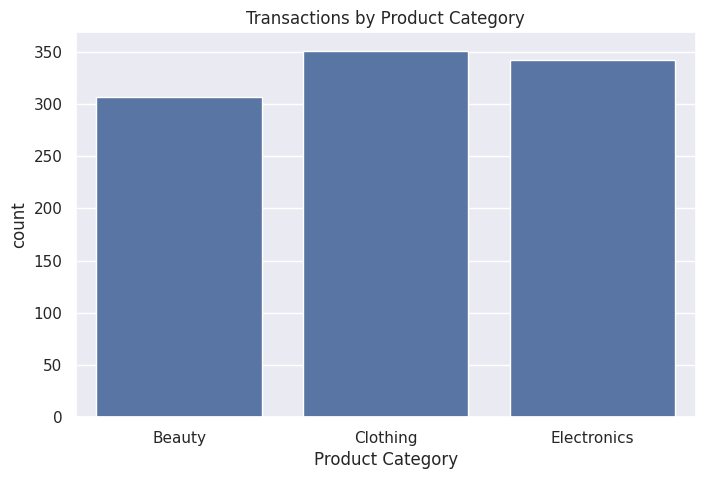

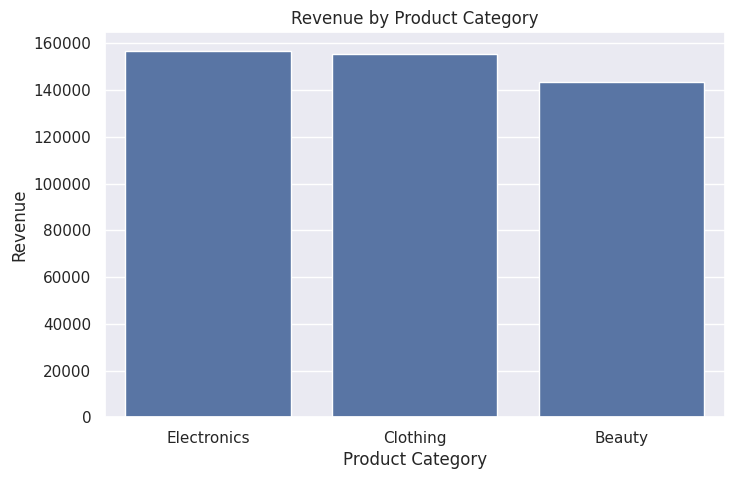

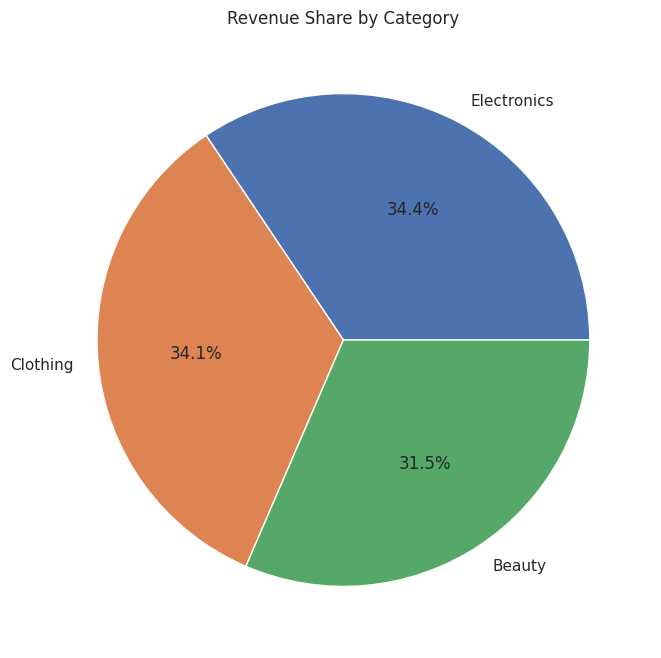

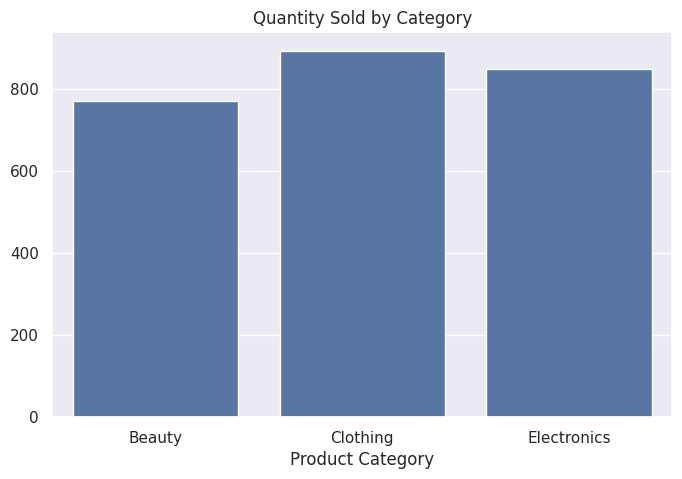

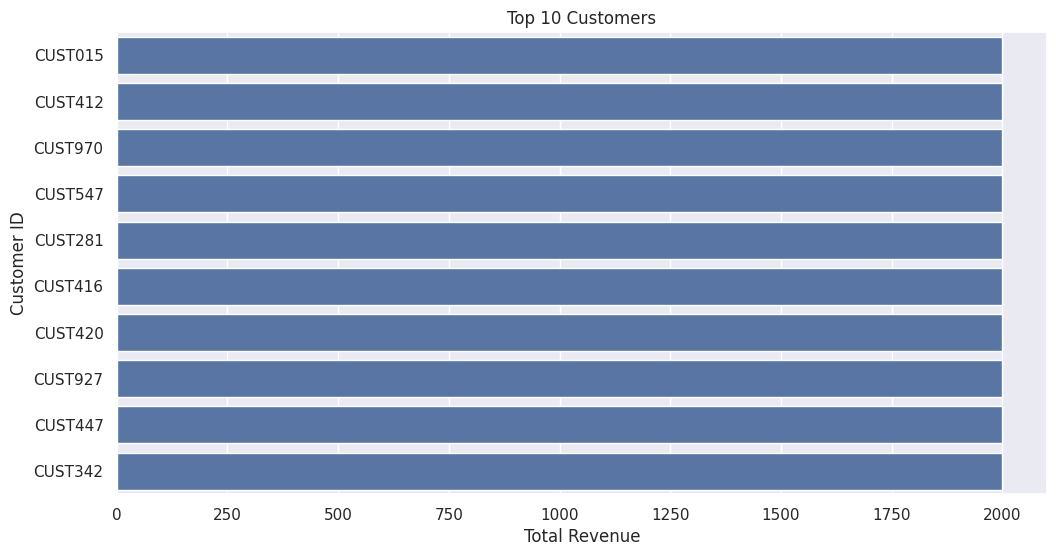

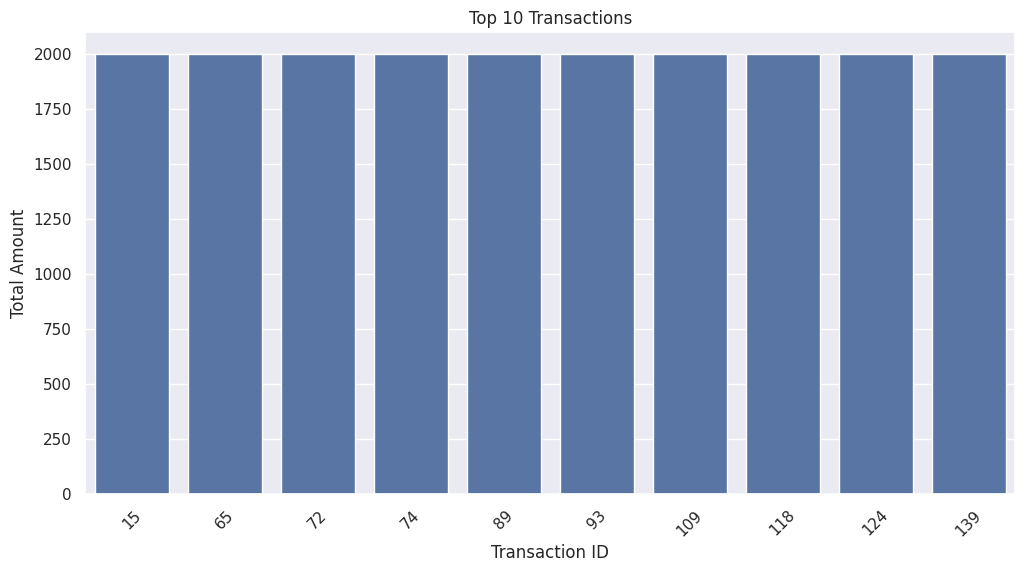

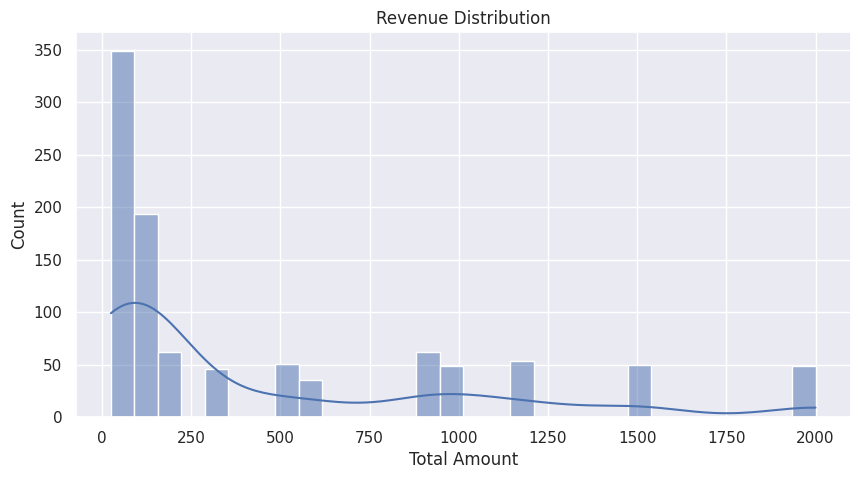

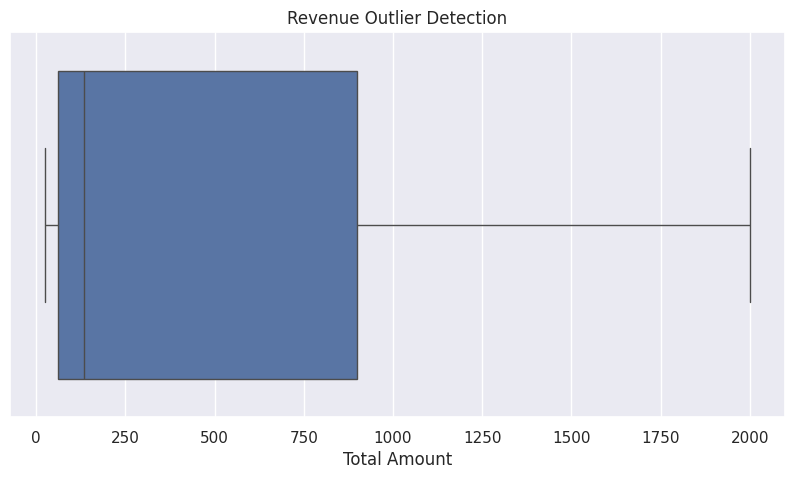

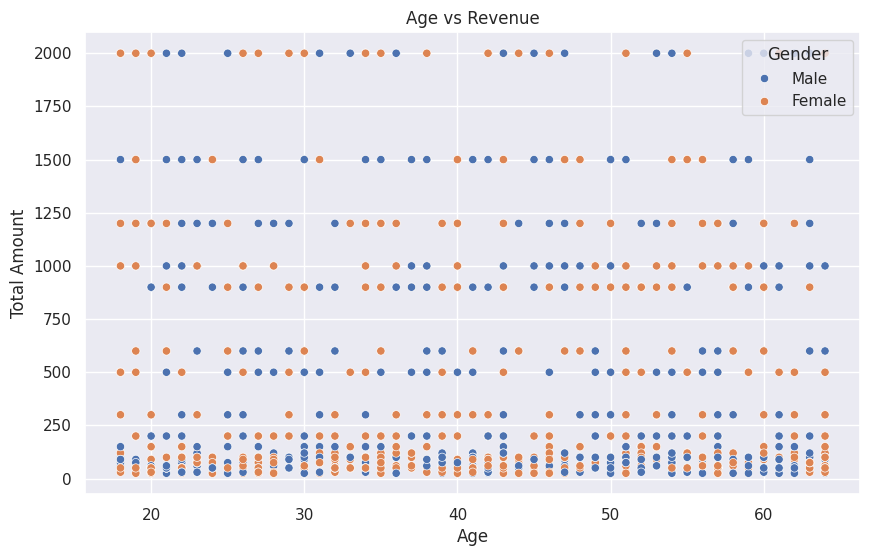

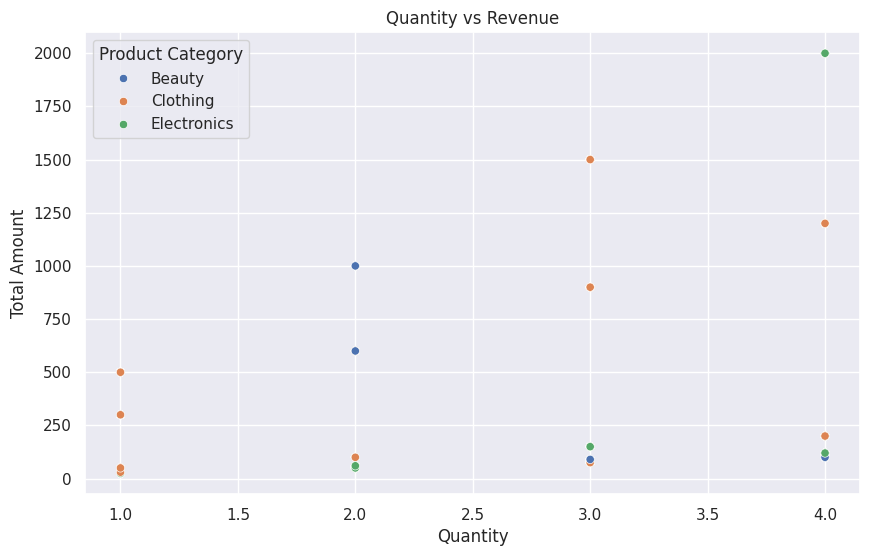

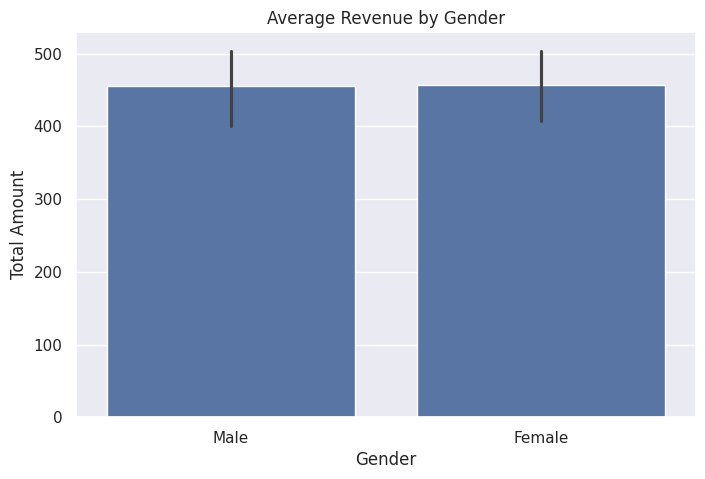

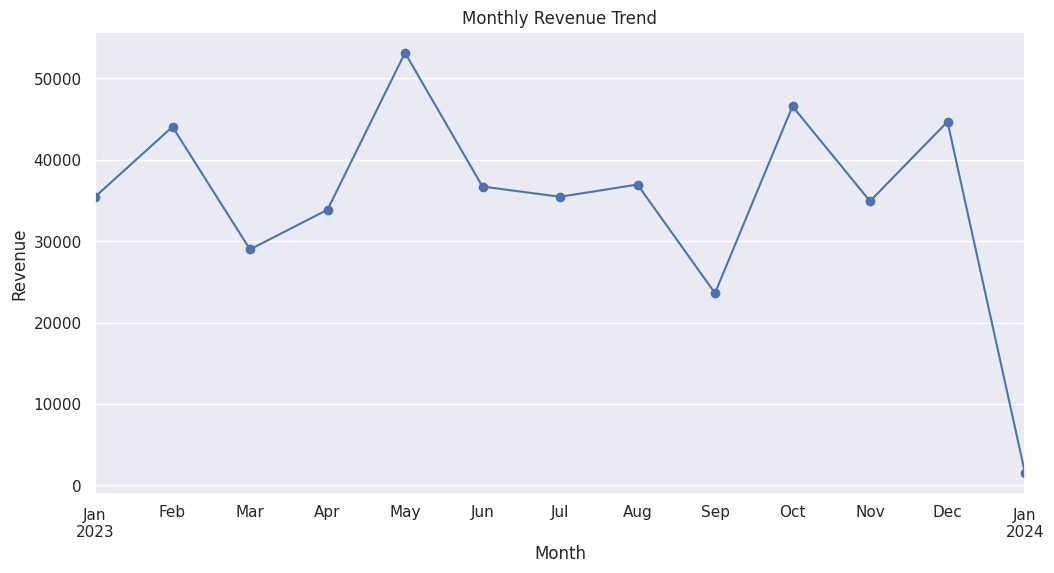

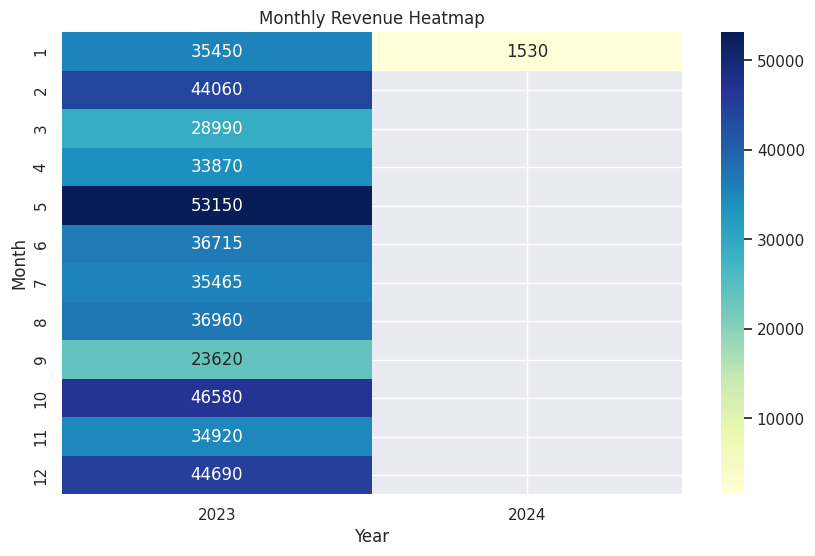

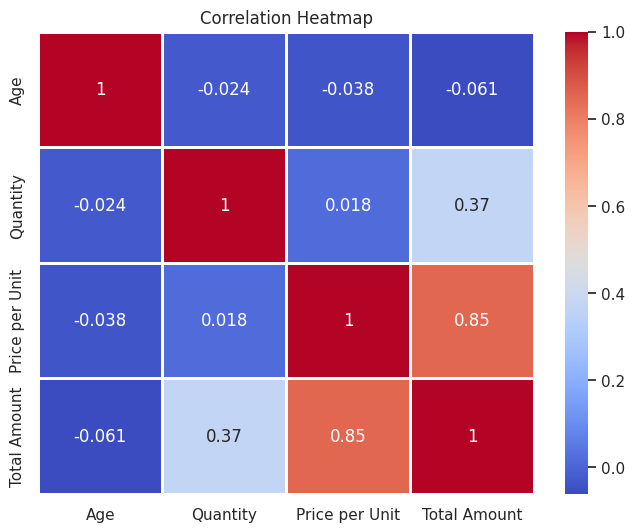

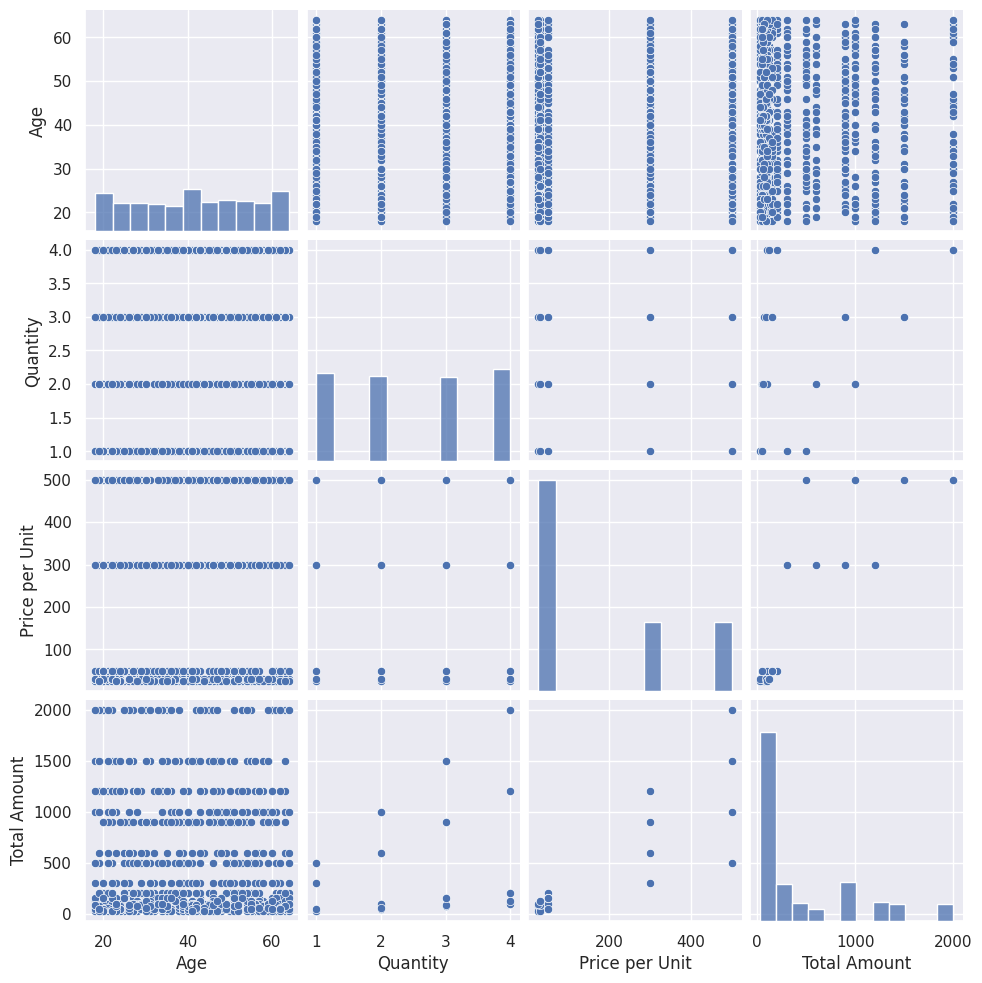


BUSINESS INSIGHTS
Total Revenue: 456000
Average Revenue: 456.0
Highest Revenue Category: Electronics
Highest Category Revenue: 156905
Lowest Revenue Category: Beauty
Lowest Category Revenue: 143515
Top Customer: CUST015

Revenue by Category
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

Top 10 Customers
Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64

EDA COMPLETED SUCCESSFULLY
Cleaned Dataset Saved As: retail_sales_cleaned.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme()


df = pd.read_csv('/content/retail_sales_dataset.csv')

print("="*60)
print("RETAIL SALES DATASET ANALYSIS")
print("="*60)

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
print(df.head())

print("\nLast 5 Records:")
print(df.tail())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

print("\nDescriptive Statistics:")
print(df.describe())

print("\nMean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nMode:")
print(df.mode().iloc[0])

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

print("\nTotal Records:", len(df))

total_sales = df['Total Amount'].sum()
average_sales = df['Total Amount'].mean()

print("\nTotal Revenue:", total_sales)
print("Average Revenue:", average_sales)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()


plt.figure(figsize=(8,8))
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Percentage')
plt.ylabel('')
plt.show()


plt.figure(figsize=(10,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()


plt.figure(figsize=(10,5))
sns.boxplot(x=df['Age'])
plt.title('Age Outlier Detection')
plt.show()


bins = [18,25,35,45,55,65]
labels = ['18-25','26-35','36-45','46-55','56-65']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age Group')
plt.title('Age Group Distribution')
plt.show()


plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Product Category')
plt.title('Transactions by Product Category')
plt.show()


category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Revenue by Product Category')
plt.ylabel('Revenue')
plt.show()


plt.figure(figsize=(8,8))
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue Share by Category')
plt.ylabel('')
plt.show()


quantity_sales = df.groupby('Product Category')['Quantity'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=quantity_sales.index, y=quantity_sales.values)
plt.title('Quantity Sold by Category')
plt.show()


top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title('Top 10 Customers')
plt.xlabel('Total Revenue')
plt.show()


top_transactions = df.nlargest(10, 'Total Amount')

plt.figure(figsize=(12,6))
sns.barplot(data=top_transactions, x='Transaction ID', y='Total Amount')
plt.title('Top 10 Transactions')
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(10,5))
sns.histplot(df['Total Amount'], bins=30, kde=True)
plt.title('Revenue Distribution')
plt.show()


plt.figure(figsize=(10,5))
sns.boxplot(x=df['Total Amount'])
plt.title('Revenue Outlier Detection')
plt.show()


plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Total Amount', hue='Gender')
plt.title('Age vs Revenue')
plt.show()


plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Quantity', y='Total Amount', hue='Product Category')
plt.title('Quantity vs Revenue')
plt.show()


plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Gender', y='Total Amount')
plt.title('Average Revenue by Gender')
plt.show()


monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()


df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

pivot = df.pivot_table(
    values='Total Amount',
    index='Month',
    columns='Year',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.0f')
plt.title('Monthly Revenue Heatmap')
plt.show()


plt.figure(figsize=(8,6))
corr = df[['Age','Quantity','Price per Unit','Total Amount']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title('Correlation Heatmap')
plt.show()


sns.pairplot(df[['Age','Quantity','Price per Unit','Total Amount']])
plt.show()

print("\n" + "="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("Total Revenue:", round(total_sales,2))
print("Average Revenue:", round(average_sales,2))
print("Highest Revenue Category:", category_sales.idxmax())
print("Highest Category Revenue:", round(category_sales.max(),2))
print("Lowest Revenue Category:", category_sales.idxmin())
print("Lowest Category Revenue:", round(category_sales.min(),2))
print("Top Customer:", top_customers.index[0])

print("\nRevenue by Category")
print(category_sales)

print("\nTop 10 Customers")
print(top_customers)

df.to_csv('retail_sales_cleaned.csv', index=False)

print("\nEDA COMPLETED SUCCESSFULLY")
print("Cleaned Dataset Saved As: retail_sales_cleaned.csv")